# FMCG Sales Performance Analysis
## Notebook 01 Data Cleaning & Feature Engineering

**Author:** Ardi Gunawan Pratama  
**Dataset:** FMCG_2022_2024.csv  
**Coverage:** Jan 2022 – Dec 2024 | 190,757 rows | 14 columns  

---
### Dataset Columns
| Column | Type | Description |
|---|---|---|
| `date` | str/date | Transaction date |
| `sku` | str | product ID |
| `brand` | str | Product brand (14 brands) |
| `segment` | str | Product segment (13 segments) |
| `category` | str | Category: Milk, Yogurt, ReadyMeal, Juice, SnackBar |
| `channel` | str | Distribution channel: Retail, Discount, E-commerce |
| `region` | str | Region: PL-Central, PL-North, PL-South |
| `pack_type` | str | Pack type: Multipack, Single, Carton |
| `price_unit` | float | Unit price |
| `promotion_flag` | int | 1 = on promotion, 0 = no promotion |
| `delivery_days` | int | Number of delivery days |
| `stock_available` | int | Available stock units |
| `delivered_qty` | int | Quantity delivered |
| `units_sold` | int | Units sold |

---

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

## Load Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file "{filename}"')
  df = pd.read_csv(filename)
  print(f'Successfully loaded "{filename}" into a pandas DataFrame.')

df.head()

Saving FMCG_2022_2024.csv to FMCG_2022_2024.csv
Uploaded file "FMCG_2022_2024.csv"
Successfully loaded "FMCG_2022_2024.csv" into a pandas DataFrame.


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


## Initial Inspection

In [3]:
# Column information and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             190757 non-null  object 
 1   sku              190757 non-null  object 
 2   brand            190757 non-null  object 
 3   segment          190757 non-null  object 
 4   category         190757 non-null  object 
 5   channel          190757 non-null  object 
 6   region           190757 non-null  object 
 7   pack_type        190757 non-null  object 
 8   price_unit       190757 non-null  float64
 9   promotion_flag   190757 non-null  int64  
 10  delivery_days    190757 non-null  int64  
 11  stock_available  190757 non-null  int64  
 12  delivered_qty    190757 non-null  int64  
 13  units_sold       190757 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 20.4+ MB


In [4]:
# Preview first 5 rows
df.head()


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [5]:
# Check for missing values
df.isnull().sum()


,0
date,0
sku,0
brand,0
segment,0
category,0
channel,0
region,0
pack_type,0
price_unit,0
promotion_flag,0


In [6]:
# Check for duplicate rows
print('duplicates: ', df.duplicated().sum())


duplicates:  0


In [7]:
# Descriptive statistics
df.describe()

,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
count,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000
mean,5.251979,0.149200,3.004860,157.697652,179.333655,19.919709
std,2.166705,0.356287,1.414626,52.736104,40.037475,11.770077
min,1.500000,0.000000,1.000000,-12.000000,-11.000000,-25.000000
25%,3.380000,0.000000,2.000000,124.000000,152.000000,12.000000
50%,5.250000,0.000000,3.000000,155.000000,179.000000,18.000000
75%,7.130000,0.000000,4.000000,192.000000,206.000000,25.000000
max,9.000000,1.000000,5.000000,405.000000,366.000000,139.000000


## Fix Data Types

In [8]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             190757 non-null  datetime64[ns]
 1   sku              190757 non-null  object        
 2   brand            190757 non-null  object        
 3   segment          190757 non-null  object        
 4   category         190757 non-null  object        
 5   channel          190757 non-null  object        
 6   region           190757 non-null  object        
 7   pack_type        190757 non-null  object        
 8   price_unit       190757 non-null  float64       
 9   promotion_flag   190757 non-null  int64         
 10  delivery_days    190757 non-null  int64         
 11  stock_available  190757 non-null  int64         
 12  delivered_qty    190757 non-null  int64         
 13  units_sold       190757 non-null  int64         
dtypes: datetime64[ns](1)

In [9]:
# Validate promotion_flag contains only binary values (0/1)
invalid_flag = df[~df["promotion_flag"].isin([0, 1])]
if not invalid_flag.empty:
    print(f"promotion_flag has {len(invalid_flag)} values outside 0/1 — clipped to 0/1")
    df["promotion_flag"] = df["promotion_flag"].clip(0, 1)
else:
    print("'promotion_flag' is valid (only 0 and 1)")

'promotion_flag' is valid (only 0 and 1)


In [10]:
# Ensure numeric columns have correct data types
for col in ["price_unit", "stock_available", "delivered_qty", "units_sold", "delivery_days"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    print(f"'{col}' : numeric")

'price_unit' : numeric
'stock_available' : numeric
'delivered_qty' : numeric
'units_sold' : numeric
'delivery_days' : numeric


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190757 entries, 0 to 190756
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   date             190757 non-null  datetime64[ns]
 1   sku              190757 non-null  object        
 2   brand            190757 non-null  object        
 3   segment          190757 non-null  object        
 4   category         190757 non-null  object        
 5   channel          190757 non-null  object        
 6   region           190757 non-null  object        
 7   pack_type        190757 non-null  object        
 8   price_unit       190757 non-null  float64       
 9   promotion_flag   190757 non-null  int64         
 10  delivery_days    190757 non-null  int64         
 11  stock_available  190757 non-null  int64         
 12  delivered_qty    190757 non-null  int64         
 13  units_sold       190757 non-null  int64         
dtypes: datetime64[ns](1)

## Handle Negative Values

The dataset contains negative values in `stock_available`, `delivered_qty`, and `units_sold`.  
In the FMCG context, negative values may occur due to **product returns** or **data entry errors**.  
We investigate these values before deciding on the appropriate treatment.

In [12]:
# Investigate columns with negative values
neg_cols = ["stock_available", "delivered_qty", "units_sold"]
for col in neg_cols:
    neg_count = (df[col] < 0).sum()
    neg_pct   = neg_count / len(df) * 100
    neg_min   = df[col].min()
    print(f"  {col:20s}: {neg_count:,} rows ({neg_pct:.2f}%)  |  min = {neg_min}")


  stock_available     : 3 rows (0.00%)  |  min = -12
  delivered_qty       : 3 rows (0.00%)  |  min = -11
  units_sold          : 3 rows (0.00%)  |  min = -25


In [13]:
# Inspect rows containing negative values
neg_mask = (df["stock_available"] < 0) | (df["delivered_qty"] < 0) | (df["units_sold"] < 0)
df[neg_mask].head(10)

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
70489,2023-07-26,SN-028,SnBrand2,SnackBar-Seg1,SnackBar,Discount,PL-South,Single,2.91,0,5,-2,-3,-3
83501,2023-09-21,SN-010,SnBrand2,SnackBar-Seg2,SnackBar,Retail,PL-Central,Carton,8.60,1,4,-12,-11,-25
123633,2024-03-14,RE-007,ReBrand4,ReadyMeal-Seg1,ReadyMeal,Discount,PL-Central,Carton,2.38,0,4,-6,-7,-8


In [14]:
# Treatment: clip to 0 (negative values treated as data entry errors / returns)
# Audit trail: create flag columns for further analysis
for col in neg_cols:
    df[f"{col}_has_negative"] = (df[col] < 0).astype(int)
    df[col] = df[col].clip(lower=0)
    print(f"'{col}' negative values clipped to 0 | audit flag saved in '{col}_has_negative'")


'stock_available' negative values clipped to 0 | audit flag saved in 'stock_available_has_negative'
'delivered_qty' negative values clipped to 0 | audit flag saved in 'delivered_qty_has_negative'
'units_sold' negative values clipped to 0 | audit flag saved in 'units_sold_has_negative'


In [15]:
# Remove temporary audit flag columns
columns_to_drop = [
    'stock_available_has_negative',
    'delivered_qty_has_negative',
    'units_sold_has_negative'
]
df.drop(columns=columns_to_drop, inplace=True)
print(f"Dropped columns: {', '.join(columns_to_drop)}")
df.head()

Dropped columns: stock_available_has_negative, delivered_qty_has_negative, units_sold_has_negative


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,1,141,128,9
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,3,0,129,0
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,5,118,161,8
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,2,81,114,7
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,4,148,204,12


In [16]:
df.describe()

,date,price_unit,promotion_flag,delivery_days,stock_available,delivered_qty,units_sold
count,190757,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000,190757.000000
mean,2023-10-28 04:11:33.514785536,5.251979,0.149200,3.004860,157.697757,179.333765,19.919898
min,2022-01-21 00:00:00,1.500000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2023-04-16 00:00:00,3.380000,0.000000,2.000000,124.000000,152.000000,12.000000
50%,2023-11-12 00:00:00,5.250000,0.000000,3.000000,155.000000,179.000000,18.000000
75%,2024-06-07 00:00:00,7.130000,0.000000,4.000000,192.000000,206.000000,25.000000
max,2024-12-31 00:00:00,9.000000,1.000000,5.000000,405.000000,366.000000,139.000000
std,NaN,2.166705,0.356287,1.414626,52.735781,40.036970,11.769602


## Outlier Detection & Handling

Using the **IQR × 3.0** method (conservative) to preserve valid business extremes.  
Treatment: **Winsorize (cap)** — not drop, as FMCG sales data can exhibit legitimate seasonal spikes.

  price_unit           →     0 outliers  | bounds [-7.87, 18.38]  | winsorized
  units_sold           → 1,607 outliers  | bounds [-27.00, 64.00]  | winsorized
  delivered_qty        →     0 outliers  | bounds [-10.00, 368.00]  | winsorized
  stock_available      →     1 outliers  | bounds [-80.00, 396.00]  | winsorized
  delivery_days        →     0 outliers  | bounds [-4.00, 10.00]  | winsorized


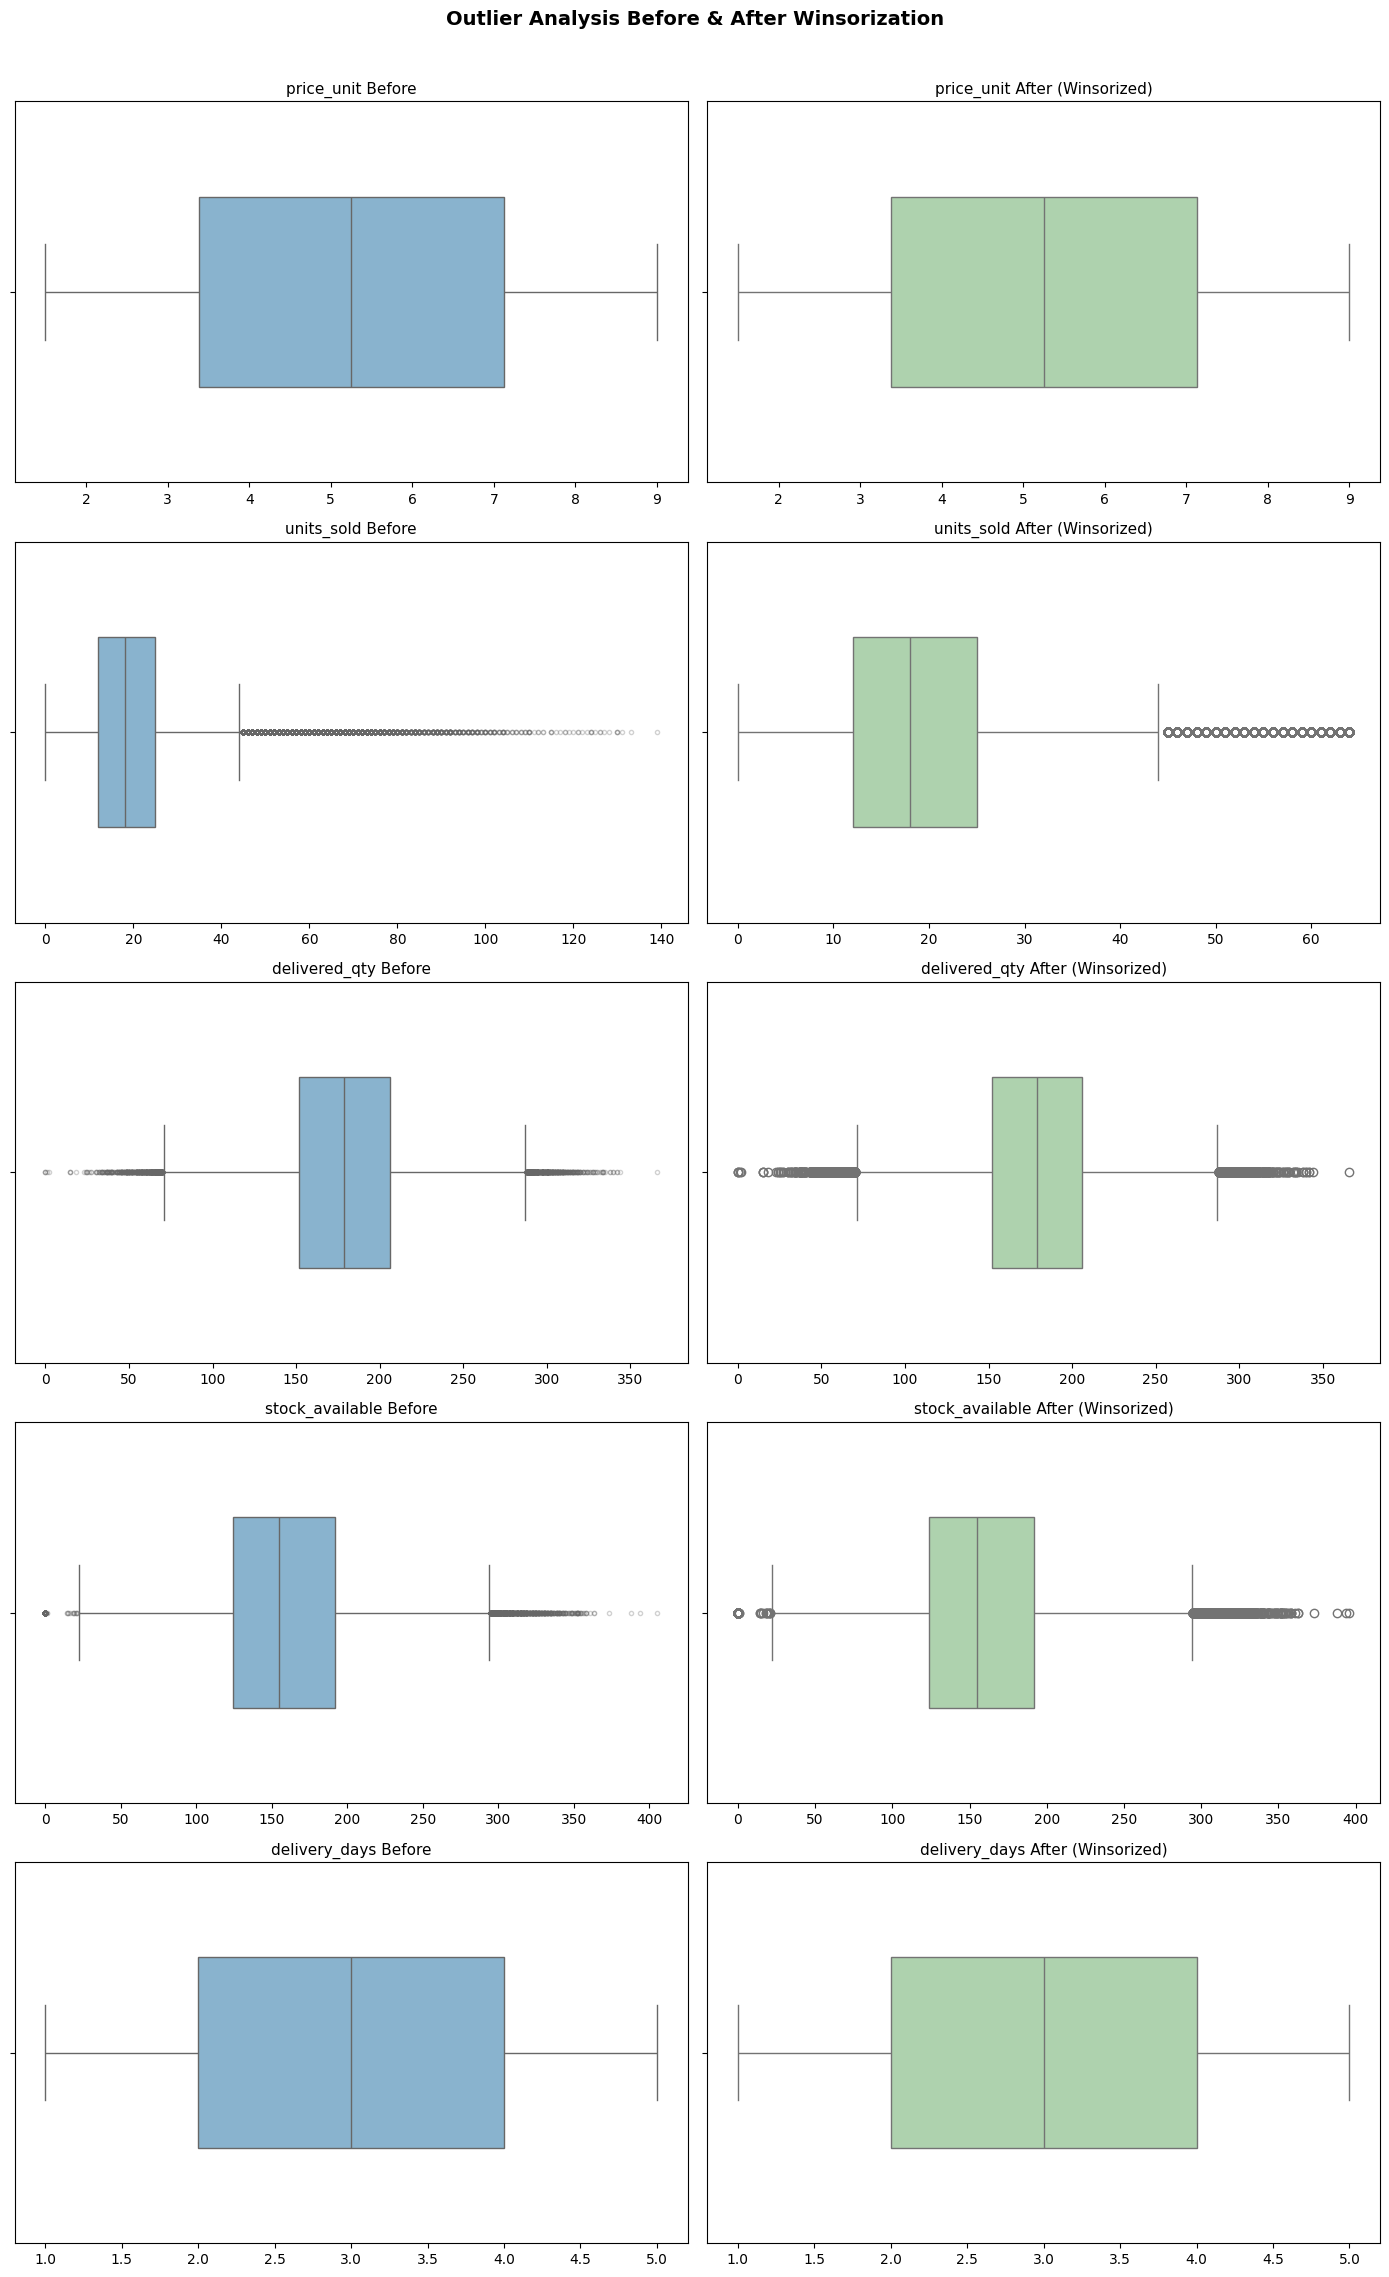

In [17]:
OUTLIER_COLS = ["price_unit", "units_sold", "delivered_qty", "stock_available", "delivery_days"]

fig, axes = plt.subplots(len(OUTLIER_COLS), 2, figsize=(14, 4.5 * len(OUTLIER_COLS)))
fig.suptitle("Outlier Analysis Before & After Winsorization", fontsize=14, fontweight="bold", y=1.01)

outlier_summary = {}

for idx, col in enumerate(OUTLIER_COLS):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

    df[f"{col}_raw"] = df[col].copy()
    df[col] = df[col].clip(lower=lower, upper=upper)

    print(f"  {col:20s} → {n_outliers:5,} outliers  | bounds [{lower:.2f}, {upper:.2f}]  | winsorized")

    # Plot
    ax0 = axes[idx][0]
    ax1 = axes[idx][1]

    sns.boxplot(x=df[f"{col}_raw"], ax=ax0, color="#7EB6D9", width=0.5, flierprops=dict(marker=".", alpha=0.3))
    ax0.set_title(f"{col} Before", fontsize=11)
    ax0.set_xlabel("")

    sns.boxplot(x=df[col], ax=ax1, color="#A8D8A8", width=0.5)
    ax1.set_title(f"{col} After (Winsorized)", fontsize=11)
    ax1.set_xlabel("")

# Drop raw audit columns
df.drop(columns=[f"{c}_raw" for c in OUTLIER_COLS if f"{c}_raw" in df.columns], inplace=True)

plt.tight_layout()
plt.show()

## Feature Engineering

Creating derived columns relevant to FMCG sales analysis.

In [18]:
# Calculate revenue (price × units sold)
df["revenue"] = (df["price_unit"] * df["units_sold"]).round(2)
print(f"   mean: {df['revenue'].mean():.2f}  |  max: {df['revenue'].max():.2f}")

   mean: 104.03  |  max: 576.00


In [19]:
# Sell-Through Rate
# Percentage of delivered quantity that was actually sold
df["sell_through_rate"] = np.where(
    df["delivered_qty"] > 0,
    (df["units_sold"] / df["delivered_qty"] * 100).round(2),
    0.0
)
df["sell_through_rate"] = df["sell_through_rate"].clip(0, 100)  # cap 0–100%
print(f"   mean: {df['sell_through_rate'].mean():.1f}%  |  median: {df['sell_through_rate'].median():.1f}%")

   mean: 11.0%  |  median: 9.9%


In [20]:
# Stock Adequacy (whether available stock meets delivery demand)
df["stock_adequate"] = (df["stock_available"] >= df["delivered_qty"]).astype(int)
pct_adequate = df["stock_adequate"].mean() * 100
print(f"   {pct_adequate:.1f}% of transactions have adequate stock")

   32.7% of transactions have adequate stock


In [21]:
# Promotion Effect
# Map promotion flag to descriptive labels
df["is_promoted"] = df["promotion_flag"].map({1: "Promoted", 0: "Non-Promoted"})
promo_avg = df.groupby("is_promoted")["units_sold"].mean().round(2)
print(f"   Average units_sold:")
print(f"   {promo_avg.to_string()}")

   Average units_sold:
   is_promoted
Non-Promoted    17.44
Promoted        33.34


In [22]:
# Time-based features
df["year"]       = df["date"].dt.year
df["month"]      = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["quarter"]    = df["date"].dt.quarter.map({1:"Q1", 2:"Q2", 3:"Q3", 4:"Q4"})
df["yearmonth"]  = df["date"].dt.to_period("M").astype(str)
df["day_of_week"]= df["date"].dt.dayofweek   # 0=Mon, 6=Sun
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print(" Time features created:")
print("   year, month, month_name, quarter, yearmonth, day_of_week, is_weekend")
print(f"\n   Date range : {df['date'].min().date()}  to  {df['date'].max().date()}")
print(f"   Years      : {sorted(df['year'].unique())}")
print(f"   Quarters   : {sorted(df['quarter'].unique())}")


 Time features created:
   year, month, month_name, quarter, yearmonth, day_of_week, is_weekend

   Date range : 2022-01-21  to  2024-12-31
   Years      : [np.int32(2022), np.int32(2023), np.int32(2024)]
   Quarters   : ['Q1', 'Q2', 'Q3', 'Q4']


In [23]:
# Delivery performance tier
bins   = [0, 1, 2, 3, 5.01]
labels = ["Same Day", "Fast (2d)", "Standard (3d)", "Slow (4-5d)"]
df["delivery_tier"] = pd.cut(df["delivery_days"], bins=bins, labels=labels, include_lowest=True)

print("delivery_tier distribution:")
print(df["delivery_tier"].value_counts().sort_index().to_string())


delivery_tier distribution:
delivery_tier
Same Day         38129
Fast (2d)        37813
Standard (3d)    38023
Slow (4-5d)      76792


## Final Validation

In [24]:
print("  FINAL VALIDATION REPORT")

print(f"\n  Rows           : {len(df):,}")
print(f"  Columns        : {len(df.columns)}")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Duplicates     : {df.duplicated().sum()}")

print("\n New Columns Added")
new_cols = [
    "revenue", "sell_through_rate", "stock_adequate", "is_promoted",
    "year", "month", "month_name", "quarter", "yearmonth",
    "day_of_week", "is_weekend", "delivery_tier"
]
for col in new_cols:
    if col in df.columns:
        print(f"  {col}")

print("\nSummary Statistics")
key = [c for c in ["price_unit","units_sold","delivered_qty","revenue","sell_through_rate"] if c in df.columns]
df[key].describe().round(2)


  FINAL VALIDATION REPORT

  Rows           : 190,757
  Columns        : 26
  Missing values : 0
  Duplicates     : 0

 New Columns Added
  revenue
  sell_through_rate
  stock_adequate
  is_promoted
  year
  month
  month_name
  quarter
  yearmonth
  day_of_week
  is_weekend
  delivery_tier

Summary Statistics


,price_unit,units_sold,delivered_qty,revenue,sell_through_rate
count,190757.00,190757.00,190757.00,190757.00,190757.00
mean,5.25,19.81,179.33,104.03,11.04
std,2.17,11.24,40.04,76.99,5.69
min,1.50,0.00,0.00,0.00,0.00
25%,3.38,12.00,152.00,50.50,7.32
50%,5.25,18.00,179.00,85.44,9.89
75%,7.13,25.00,206.00,136.00,13.42
max,9.00,64.00,366.00,576.00,62.14


## Quick Visual Summary

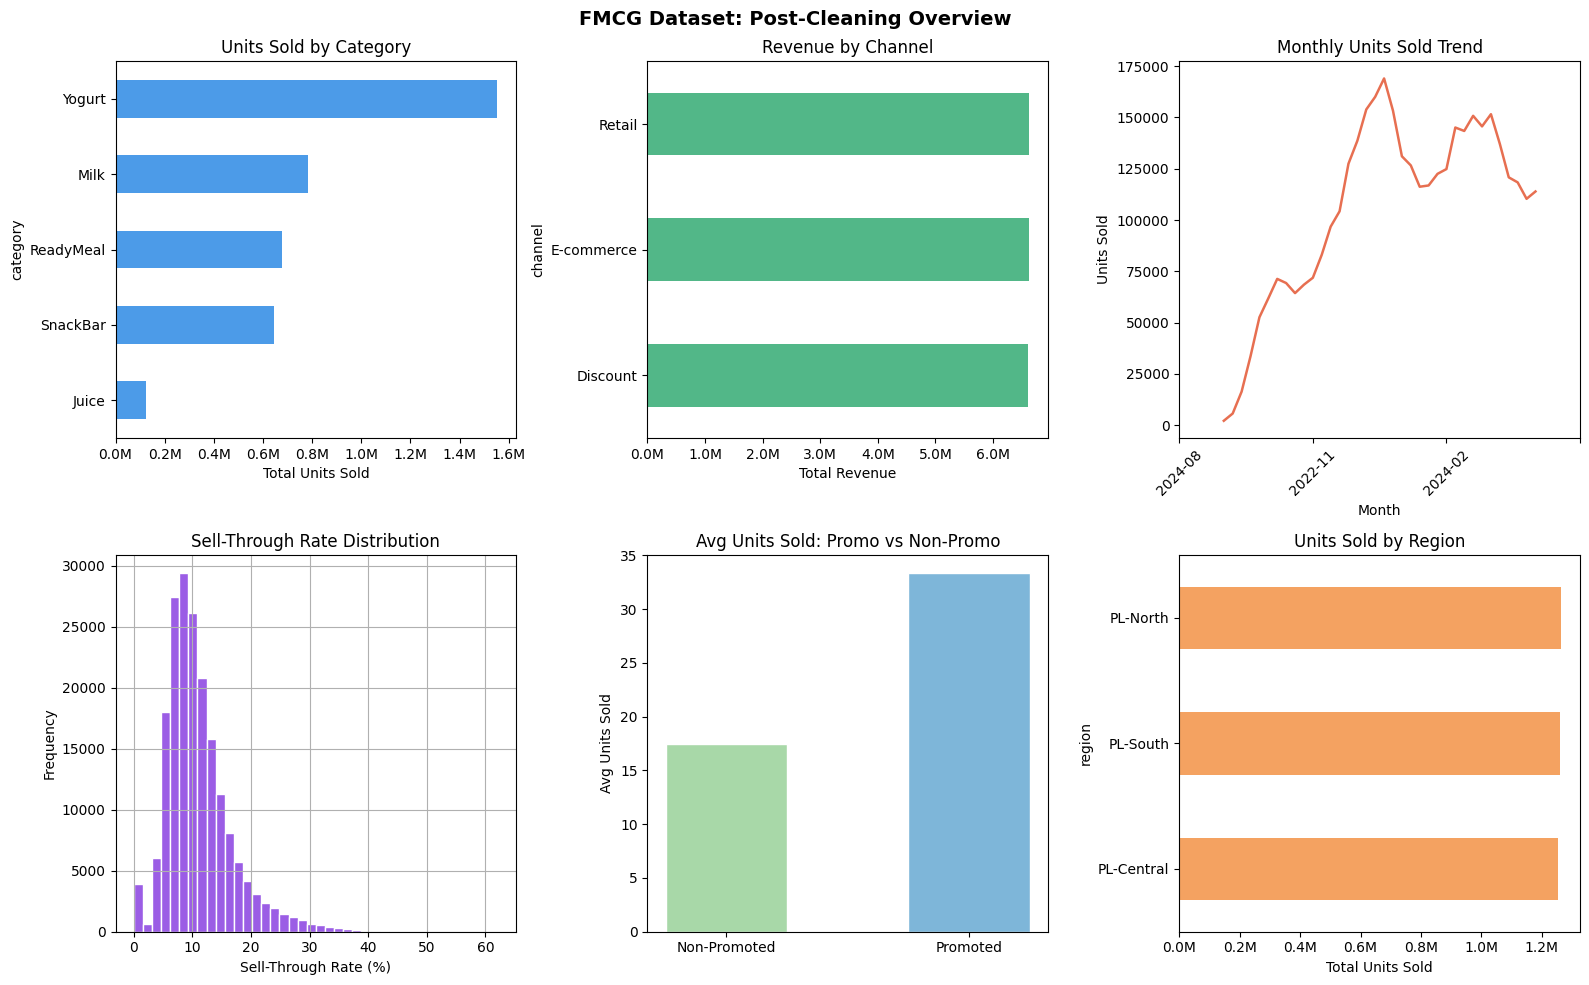

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("FMCG Dataset: Post-Cleaning Overview", fontsize=14, fontweight="bold")

# 1. Units sold by category
ax = axes[0][0]
cat_sales = df.groupby("category")["units_sold"].sum().sort_values(ascending=True)
cat_sales.plot(kind="barh", ax=ax, color="#4C9BE8")
ax.set_title("Units Sold by Category")
ax.set_xlabel("Total Units Sold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

# 2. Revenue by channel
ax = axes[0][1]
ch_rev = df.groupby("channel")["revenue"].sum().sort_values(ascending=True)
ch_rev.plot(kind="barh", ax=ax, color="#52B788")
ax.set_title("Revenue by Channel")
ax.set_xlabel("Total Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

# 3. Monthly units sold trend
ax = axes[0][2]
monthly = df.groupby("yearmonth")["units_sold"].sum()
monthly.plot(ax=ax, color="#E76F51", linewidth=1.8)
ax.set_title("Monthly Units Sold Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
ax.set_xticks(ax.get_xticks()[::3])
ax.tick_params(axis="x", rotation=45)

# 4. Sell-through rate distribution
ax = axes[1][0]
df["sell_through_rate"].hist(bins=40, ax=ax, color="#9B5DE5", edgecolor="white")
ax.set_title("Sell-Through Rate Distribution")
ax.set_xlabel("Sell-Through Rate (%)")
ax.set_ylabel("Frequency")

# 5. Promo vs Non-Promo units sold
ax = axes[1][1]
promo_data = df.groupby("is_promoted")["units_sold"].mean().reset_index()
ax.bar(promo_data["is_promoted"], promo_data["units_sold"],
       color=["#A8D8A8","#7EB6D9"], edgecolor="white", width=0.5)
ax.set_title("Avg Units Sold: Promo vs Non-Promo")
ax.set_ylabel("Avg Units Sold")

# 6. Units sold by region
ax = axes[1][2]
reg_data = df.groupby("region")["units_sold"].sum().sort_values(ascending=True)
reg_data.plot(kind="barh", ax=ax, color="#F4A261")
ax.set_title("Units Sold by Region")
ax.set_xlabel("Total Units Sold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

## Save Cleaned Dataset

In [26]:
df.to_csv('cleaned_FMCG_data.csv', index=False)
print('Cleaned dataset saved as cleaned_FMCG_data.csv')


Cleaned dataset saved as cleaned_FMCG_data.csv


In [27]:
from google.colab import files
files.download('cleaned_FMCG_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>